<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica Aplicada I 

## ANÁLISE DE VIGAS

### Problema 1 <a name="PI"></a>

A viga AB representada na Figura encontra-se apoiada em A e B através de um apoio fixo e móvel, respetivamente. Quanto ao carregamento, considere um momento exterior aplicado em A de 5 kN $\cdot$ m e uma carga distribuída entre A e B definida pela função quadrática $kx^2$.

[a)](#A) Calcule as reações nos apoios.

[b)](#B) Determine as expressões do esforço transverso e do momento fletor.

[c)](#C) Traçe os diagramas dos esforços internos indicando o valor máximo do  momento fletor.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P1/MAI_Ch08_P1.jpg"
width="500">

#### Resumo

**Determinação de Esforços em vigas**

Quando submetido a forças externas, pela condição de equilíbrio, um elemento estrutural desenvolve forças internas. Este sistema de forças, num dado ponto ou secção, pode reduzir-se a um sistema força-binário equivalente. Projetanto estas quantidasdes vetoriais em eixos solidários com o elemento estrutural é possivel definir forças normais (de tração e compressão), forças de corte e momento fletor.

Metodologia:
```
    - Definir o diagrama de corpo livre;
    - Determinar reações nos apoios;
    - Determinar os esforços internos (e.g. esforço transverso e momento fletor);
    - Desenhar os diagramas de esforço transverso e momento fletor.
```

Programas de análise estrutural:

- [Ftool](https://www.ftool.com.br/Ftool/)
- [ANSYS Student](https://www.ansys.com/academic/free-student-products)
- [Robot Structural Analysis Professional](https://www.autodesk.com/education/free-software/featured)


### Resolução

#### a) Calcule as reações nos apoios. <a id="A"></a> ([_enunciatum_](#PI))

**Definição do carregamento distribuído aplicado**

A carga distribuída é dada pela função polinomial $y(x) = k x^2$. A constante $k$ pode ser determinada considerando as condições de fronteira do problema, expressas pelas restrições da função:

\begin{equation*}
\begin{cases}
x = 0: &\quad y = 0 \\
x = L: &\quad y = F_\textrm{max} \\
\end{cases}
\quad\Rightarrow\quad~
F_\textrm{max} = k L^2
~\Leftrightarrow~
k = \frac{F_\textrm{max}}{L^2}
\end{equation*}

Pelo que a carga distribuida vem expressa em função dos dados do problema por,

\begin{equation*}
y(x) \equiv w(x) = kx^2 = \frac{F_\textrm{max}}{L^2} x^2
= 2\,x^2
\end{equation*}

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve

x, k, f = sy.symbols('x k f')

def func(x):
    return k * x**2 - f

L, Fmax = 3., 18.  # unit: m, kN

# Assuming you want to solve func(x) = Fmax
sol = sy.solve(func(x).subs({x: L, f: Fmax}), k)
k = sol[0]

#k = Fmax/L**2
print(f'k = {k:.1f} [kN/m²]')

k = 2.0 [kN/m²]


**Força resultante equivalente ao carregamento distribuído aplicado**

Para o cálculo das reações (forças de superfície que se desenvolvem nos apoios ou pontos de contato entre os corpos) é conveniente substituir a força distribuída por uma força resultante aplicada no centroide da área geométrica definida pelo carregamento. Nota-se que a força resultante equivalente ao carregamento distribuido parabólico é apenas usada para efeitos de cálculo das reações e não para o efeito da determinação dos diagrama de esforços.

Para tal, considere-se um elemento de viga infinitesimal ($\mathrm{d}x$). Se nesse elemento estiver aplicada uma força distribuida ($w$), a resultante da força aplicada ($\mathrm{d}F$) pode ser aproximada pela regra do retângulo,

\begin{equation*}
\mathrm{d}F = w(x)\mathrm{d}x
\end{equation*}

Por integração ao longo do comprimento da viga, obtém-se a resultante da força distribuída

\begin{equation*}
F = \int_0^L w(x)\mathrm{d}x
= \int_0^L 2x^2\,\mathrm{d}x
= 2\left[\frac{x^3}{3}\right]_0^L = \frac{2L^3 }{3} = 18~\textrm{kN}
\end{equation*}

In [12]:
from scipy import integrate
# scipy.integrate is a module that contains functions for integration.
# Integration can be performed on a function defined by a lambda
# Integration can also be performed given an array of y values

w = lambda z : k*z**2
Resultante = integrate.quad(w,0,L)
F = Resultante[0]
print(f' F = {F:.1f} [kN]')

 F = 18.0 [kN]


Em alternativa o resultado anterior poderia ser obtido pelo desenvolvimento do seguinte integral de área definido pelos limites de integração,

\begin{equation*}
F = \int\mathrm{d}A =\int_0^L\int_0^{2x^2}
\mathrm{d}y\mathrm{d}x
= \int_0^L [y]_{\large 0}^{\large 2x^2} \mathrm{d}x
= \int_0^L 2x^2 \mathrm{d}x = \displaystyle\frac{2L^3 }{3} = 18~\textrm{kN}
\end{equation*}

**Definição do centróide da área definida pelo carregamento distribuído aplicado**

A força equivalente do carregamento distribuído atua ao longo da uma linha de acção que contem o centróide da área definida pela curva $w(x)$. O valor do centróide pode ser calculado de acordo com a expressão:

\begin{equation*}
\overline{x}
= \displaystyle\frac{\displaystyle\int x\,\mathrm{d}A
}{\displaystyle\int \mathrm{d}A}
= \displaystyle\frac{\displaystyle\int_{x_1}^{x_2}w(x)x~\mathrm{d}x
}{\displaystyle\int_{x_1}^{x_2} w(x)\mathrm{d}x}
= \displaystyle\frac{\displaystyle\int_{0}^{L}(2\,x^2)x~\mathrm{d}x
}{F} =
\frac{3}{L^3}\left[\frac{x^4}{4}\right]_{0}^{L}
= \frac{3L}{4}
= 2.25~\textrm{m}
\end{equation*}

In [3]:
wx = lambda z : k*z**2*z
i1 = integrate.quad(wx,0,L)
print(f'int (wx) dx = {i1[0]:.1f}')
xcent = i1[0]/F
print(f'      xcent = {xcent:.3f} [m]')

int (wx) dx = 40.5
      xcent = 2.250 [m]


O resultado anterior poderia ser obtido igualmente pelo seguinte desenvolvimento,

\begin{equation*}
\overline{x}
= \frac{Q_y}{A} = \frac{\displaystyle\int x\,\mathrm{d}A}{\displaystyle\int \mathrm{d}A}
= \displaystyle\frac{\displaystyle\int_{0}^{L}
\int_0^{2x^2} x\,\mathrm{d}y\mathrm{d}x}{F}
= \frac{1}{F} \displaystyle\displaystyle\int_{0}^{L}(2\,x^2)x~\mathrm{d}x
 =
\frac{3}{L^3}\left[\frac{x^4}{4}\right]_{0}^{L}
= \frac{3L}{4}
= 2.25~\textrm{m}
\end{equation*}

Nos apoios o deslocamento/rotação é prescrito. Existirá nesse ponto uma força/momento.

O equilíbrio estático da viga plana permite escrever o seguinte sistema de equações escalares:

\begin{equation*}
\begin{cases}
\rightarrow(+)&:& \sum F_x = 0 \\
\uparrow(+) &:&\sum F_y = 0 \\
\circlearrowleft(+)&:& \sum M_A = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
R_{Ax} = 0 \\
R_{Ay} + R_{By} - F = 0 \\
-M + R_{By}\cdot L - F \cdot \overline{x} = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
R_{Ax} = 0~\textrm{kN}\\
R_{Ay} = 2.83~\textrm{kN} \\
R_{By} = 15.17~\textrm{kN}
\end{cases}
\end{equation*}

In [4]:

M = 5 # unit: kN.m (momento externo diretamente aplicado)

rax, ray, rby = sy.symbols('rax ray rby')

print('-------------------')
print('Sistema de equações')
print('-------------------')
sumFx = rax
print('Sum Fx :',sumFx)
sumFy = ray + rby - F
print('Sum Fy :',sumFy)
sumMA = -M + rby*L - F*xcent
print('Sum sumMA :',sumMA)
sol = solve({sumFx,sumFy, sumMA},{rax, ray, rby})

-------------------
Sistema de equações
-------------------
Sum Fx : rax
Sum Fy : ray + rby - 18.0
Sum sumMA : 3.0*rby - 45.5


In [5]:
print('-------------------')
print('Reações')
print('-------------------')
RAx = sol[rax]
print(f'RAx  = {RAx:.2f} kN')
RAy = sol[ray]
print(f'RAy  = {RAy:.2f} kN')
RBy = sol[rby]
print(f'RBy  = {RBy:.2f} kN')

-------------------
Reações
-------------------
RAx  = 0.00 kN
RAy  = 2.83 kN
RBy  = 15.17 kN


#### b) Determine as expressões do esforço transverso e do momento fletor.  <a id="B"></a> ([_enunciatum_](#PI))

A aplicação do método dos secções permite a determinação analítica dos esforços numa secção de uma viga. Escolhe-se um referencial global onde a origem do eixo das abcissas é o apoio A. O método das secções será desenvolvido considerando este referencial global. (Esta abordagem contrasta com um outro procedimento que consiste em considerar referenciais locais para cada troço de uma viga em estudo.)

Na aplicação do método das secções no troço AB, procede-se ao corte da viga para uma distância genérica $x$ do apoio em A (origem do referencial). Para que a viga permaneça em equilíbrio, é necessário que, no DCL da figura abaixo, se considerem os três esforços internos na viga:
- $N(x)$ : esforço normal;
- $V(x)$ : esforço transverso;
- $M(x)$ : momento fletor.

Saliente-se que este esforços são, de acordo com a convenção de sinais utilizada, positivos.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P1/MAI_Ch08_P1a.jpg"
style="max-width: 100%;"/>

**Troço $~0<x<L$**

**Abordagem 1**

Pela análise do equilíbrio estático do DCL, é possível determinar as expressões polinomiais que descrevem, em cada troço, o esforço tranverso, $V(x)$ e momento fletor $M(x)$. Os gráficos dessas funções são designados por diagramas de esforços. Desenvolvendo as expressões de equilíbrio resulta:

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_{B'} = 0 \\
\end{cases}~\Leftrightarrow~
\begin{cases}
N(x) = 0 \\
R_{Ay} - \displaystyle\int_0^xw(x)\mathrm{d}x - V(x) = 0 \\
- M - R_{Ay} \cdot x+
\displaystyle\int_0^xw(x)\mathrm{d}x\left(x-\frac{\displaystyle\int_0^xw(x)x\mathrm{d}x}{\displaystyle\int_0^xw(x)\mathrm{d}x}\right) +M(x)= 0 \\
\end{cases}
\end{equation*}

\begin{equation*}
\qquad\qquad~\Leftrightarrow~
\begin{cases}
R_{Ay} - \displaystyle\int_0^x 2x^2\mathrm{d}x - V(x) = 0 \\
-M - R_{Ay} \cdot x+
\displaystyle\int_0^x 2x^2 \mathrm{d}x\left(x-\frac{\displaystyle\int_0^x 2x^2
x\mathrm{d}x}{\displaystyle\int_0^x 2x^2\mathrm{d}x}\right) +M(x)= 0 \\
\end{cases}
\end{equation*}

\begin{equation*}
\qquad\qquad~\Leftrightarrow~
\begin{cases}
V(x) =  2.833 - 0.667x^3 ~\textrm{kN} \\
M(x) =  -0.167x^4 + 2.833 x + 5.0  ~\textrm{kN.m}
\end{cases}
\end{equation*}

In [6]:
def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

v, m, x = sy.symbols('v m x')

print('-------------------------------------------')
print('Calculos intermédios & Sistema de equações')
print('-------------------------------------------')
f = k*x**2 # integrant function
ii1 = sy.integrate(f, (x,0,x))
print('ii1 = ',printsymSF(ii1))
sumFx = RAy - ii1 - v
print('sumFx = ',printsymSF(sumFx))
f = k*x**2*x # integrant function
ii2 = sy.integrate(f, (x,0,x))
print('ii2 = ',printsymSF(ii2))

sumMA = - M - RAy*x + ii1*(x-ii2/ii1) + m
print('sumMA = ',printsymSF(sumMA))


-------------------------------------------
Calculos intermédios & Sistema de equações
-------------------------------------------
ii1 =  0.667*x**3
sumFx =  -1.0*v - 0.667*x**3 + 2.833
ii2 =  0.5*x**4
sumMA =  1.0*m + 0.167*x**4 - 2.833*x - 5.0


In [7]:
print('\n-------------------')
print('Eforços')
print('-------------------')
sol = solve({sumFx,sumMA},{v,m})
Vx = sol[v]
print(f'V(x) = {printsymSF(Vx)} [kN]')
Mx = sol[m]
print('M(x) = ',printsymSF(Mx),' [kN.m]')


-------------------
Eforços
-------------------
V(x) = 2.833 - 0.667*x**3 [kN]
M(x) =  -0.167*x**4 + 2.833*x + 5.0  [kN.m]



**Abordagem 2**

Pelo facto do problema definir uma viga única com um carregamento distribuído ao longo de toda a sua extensão, por simplicidade, as expressões dos esforços transverso e momento fletor da viga podem ser determinadas diretamente recurrendo ao seguinte formulário,

\begin{equation*}
V(x) - V_A = -\int_0^x w(x) \mathrm{d}x
\Leftrightarrow
V(x) = R_{Ay} - \int_0^x 2x^3 \mathrm{d}x
\end{equation*}


\begin{equation*}
M(x) - M_A = \int_0^x V(x) \mathrm{d}x
\Leftrightarrow
M(x) = 5 + \int_0^x 2.833 - 0.667x^3 \mathrm{d}x
\end{equation*}

De notar que no desenvolvimento da expresão anterior, $M_A$ é considerado positivo no sentido horário (corte à esquerda). Neste caso portanto o valor de $M_A = -1$ kN.m.

desenvolvendo,

\begin{equation*}
M(x) = 5 + \left[2.833x - 0.667\frac{x^4}{4} \right]_0^x
\Leftrightarrow
M(x) = -0.167x^4 + 2.833 x + 5.0  ~\textrm{kN.m}
\end{equation*}


In [8]:
vii, mii = sy.symbols('vii mii')

print('-------------------------------------------')
print('Sistema de equações & Eforços (v2)')
print('-------------------------------------------')
print('ii1 = ',printsymSF(ii1))
expVx = vii - RAy + ii1
print(f'expVx = {printsymSF(expVx)}')
sol = solve(expVx,vii)
Vx2 = sol[0]
print(f'--->>>> V(x) = {printsymSF(Vx2)} [kN]')
ii3 = sy.integrate(Vx2, (x,0,x))
print(f'ii3 = {printsymSF(ii3)}')
expMx = mii - M - ii3
print(f'expMx = {printsymSF(sumMA)}')
sol = solve(expMx,mii)
Mx2 = sol[0]
print('--->>>> M(x) = ',printsymSF(Mx2),' [kN.m]')

-------------------------------------------
Sistema de equações & Eforços (v2)
-------------------------------------------
ii1 =  0.667*x**3
expVx = 1.0*vii + 0.667*x**3 - 2.833
--->>>> V(x) = 2.833 - 0.667*x**3 [kN]
ii3 = x*(2.833 - 0.167*x**3)
expMx = 1.0*m + 0.167*x**4 - 2.833*x - 5.0
--->>>> M(x) =  -0.167*x**4 + 2.833*x + 5.0  [kN.m]


#### c) Traçe os diagramas dos esforços internos indicando o valor máximo do momento fletor.  <a id="C"></a> ([_enunciatum_](#PI))

O valor do esforço transverso e do momento fletor em $A$ e $B$ obtém-se substituindo o valor da coordenada $x$ nestes dois pontos nas equações analíticas dos esforços. Por outro lado é possível identificar a secção de momento fletor máximo e a sua posição. Este valor é determinante nomeadamente no contexto de dimensionamento de uma viga.

In [9]:
print('----------------------')
print('Eforços (pontos A e B)')
print('----------------------')
xi, xf = 0, L
print(f'V(0) = {Vx.subs(x,xi):.3f} kN')
print(f'V(L) = {Vx.subs(x,xf):.3f} kN')
print(f'\nM(0) = {Mx.subs(x,xi):.3f} kN.m')
print(f'M(L) = {Mx.subs(x,xf)} kN.m')

----------------------
Eforços (pontos A e B)
----------------------
V(0) = 2.833 kN
V(L) = -15.167 kN

M(0) = 5.000 kN.m
M(L) = 0 kN.m


----------------------
Momento fletor máximo
----------------------
V(x) = 0 >>> x =  1.620  m
Mmax(x.V=0)  =  8.442  kN.m
max(Mplot)   =  8.442  kN.m (verification)


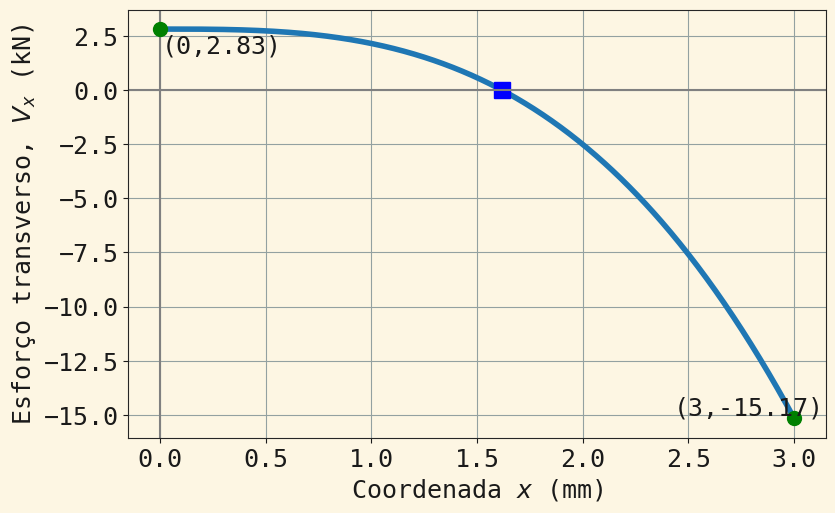

In [10]:
xp = np.linspace(0,L,1000)

import matplotlib.pyplot as plt

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

Vplot = sy2array(Vx,xp) #
Mplot = sy2array(Mx,xp) #

sol1 = solve(Vx,x)
xVzero = sol1[0]

print('----------------------')
print('Momento fletor máximo')
print('----------------------')
print('V(x) = 0 >>> x = ','{:.3f}'.format(xVzero),' m')
Mmax = Mx.subs(x,xVzero)
print('Mmax(x.V=0)  = ','{:.3f}'.format(Mmax),' kN.m')
print('max(Mplot)   = ','{:.3f}'.format(np.max(Mplot)),' kN.m (verification)')

#font = {'family' : 'Segoe UI',
#        'style'  : 'normal',
#        'weight' : 'normal',
#        'size'   : 20}

#plt.rc('font', **font)

plt.figure(figsize=(9,5.56))
plt.plot(xp,Vplot,linewidth=4)
plt.plot(xVzero,Vx.subs(x,xVzero),'bs',markersize=12)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.plot(xp[0],Vplot[0],'go',markersize=10)
plt.text(xp[0]+.01,Vplot[0]*.6,f'({xp[0]:.0f},{Vplot[0]:.2f})',fontsize=18)
plt.plot(xp[-1],Vplot[-1],'go',markersize=10)
plt.text(xp[-1]*.81,Vplot[-1]*.99,f'({xp[-1]:.0f},{Vplot[-1]:.2f})',fontsize=18)
plt.grid(True)
plt.show()


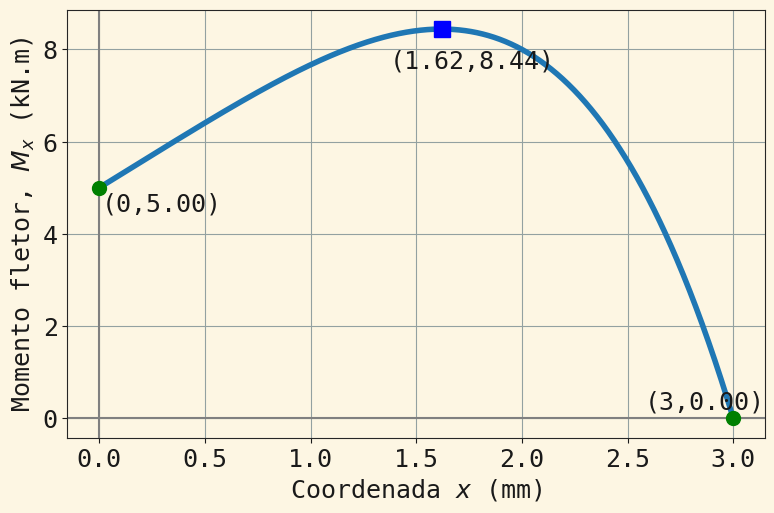

In [11]:
plt.figure(figsize=(9,5.56))
plt.plot(xp,Mplot,linewidth=4)
plt.plot(xVzero,Mx.subs(x,xVzero),'bs',markersize=12)
plt.text(xVzero*0.85,Mmax*.9,f'({xVzero:.2f},{Mmax:.2f})',fontsize=18)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Momento fletor, $M_{x}$ (kN.m)')
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.plot(xp[0],Mplot[0],'go',markersize=10)
plt.text(xp[0]+.01,Mplot[0]*.9,f'({xp[0]:.0f},{Mplot[0]:.2f})',fontsize=18)
plt.plot(xp[-1],Mplot[-1],'go',markersize=10)
plt.text(xp[-1]*.86,Mplot[-1]+.2,f'({xp[-1]:.0f},{Mplot[-1]:.2f})',fontsize=18)
plt.grid(True)
plt.show()

### Anexo: resumo

Considere-se a viga genérica como ilustrado na figura abaixo solicitada pelos carregamentos distribuídos: $p(x)$, $n(x)$ e $m(x)$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P1/MAI_Ch08_P1_Ti.jpg"
width="1000"/>

Note-se que neste caso, ao contrário da análise das treliças em que as forças eram concentradas apenas nos nós extremos das barras, as forças e momentos aplicados são distribuídos ao longo do eixo dos elementos.

Se se dividir a viga no seu ponto arbitrário C ($\{x_C\in \mathbb {R} \mid x_A< x_C <x_B\}$) as partes direita e esquerda da viga manter-se-ão em equilíbrio estático se se considerarem três esforços internos. Contrariamente às treliças onde as barras desenvolvem apenas um esforço interno (esforço normal, $N$), as vigas podem desenvolver mais dois esforços: o esforço transverso (perpendicular ao eixo da viga, $V$) e o momento fletor (que impõe uma rotação ao eixo da viga, $M$). Se para o caso das treliças os esforços de tração são positivos, a convenção de sinais adotada nas vigas está representada nas figuras abaixo.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P1/MAI_Ch08_P1_Tii.jpg"
width="1000"/>

Aquando do cálculo das reações nos apoios, as cargas distribuídas devem ser
analisadas através de forças ou momentos equivalentes:

- No caso do momento equivalente ($M_{eq}$) faz-se:

    \begin{equation*}
    M_{eq} = \int_0^L m(x)\,\mathrm{d}x
    \end{equation*}

Como a posição de $M_{eq}$ não interessa, pois trata-se de um vetor livre.

- No caso do carregamento normal equivalente ($N_{eq}$) tem-se:

    \begin{equation*}
    N_{eq} = \int_0^L n(x)\,\mathrm{d}x
    \end{equation*}

Apesar de não ser um vetor livre, considera-se que a linha de ação de $N_{eq}$ está ao nível do eixo da barra (não produz momentos em torno dos apoios A ou B).

- Analogamente, no caso do carregamento transversal equivalente ($P_{eq}$)
tem-se:

    \begin{equation*}
    P_{eq} = \int_0^L p(x)\,\mathrm{d}x
    \end{equation*}

para o cálculo das reações na viga pelo efeito do carregamento transversal, deve-se proceder ao cálculo da posição de $P_{eq}(\overline{X})$ de acordo com:

\begin{equation*}
\overline{X} \cdot P_{eq} = \int_0^L x \cdot p(x)\,\mathrm{d}x
\end{equation*}

onde o cálculo do integral é comparável ao momento estático de uma superfície plana relativamente ao eixo vertical $y$.

Estabelecem-se agora as relações entre os carregamentos e os esforços internos. Para isso, considera-se a figura abaixo. Isola-se um troço de comprimento infinitesimal dx (troço CC’) da viga.


<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P1/MAI_Ch08_P1_Tiii.jpg"
width="1000"/>

- Relação esforço normal-carga distribuída (horizontal)

A relação entre o esforço normal, $N(x)$ e o carregamento normal, $n(x)$ obtém do equilíbrio estático de todas as forças horizontais, ou seja:

\begin{equation*}
\sum F_x = 0
\quad\Leftrightarrow\quad
N_D - N_C = -\int_{x_C}^{x_D} n(x)\,\mathrm{d}x
\end{equation*}

em que o integral na equação corresponde à área sob a curva $n(x)$ entre os
pontos C e D da viga.

- Relação esforço transverso-carga distribuída (vertical)

A relação entre o esforço transverso, $V(x)$, e o carregamento transversal, $p
(x)$, é obtida a partir do equilíbrio estático de todas as forças verticais,
o que conduz a:

\begin{equation*}
\sum F_y = 0
\quad\Leftrightarrow\quad
V_D - V_C = -\int_{x_C}^{x_D} p(x)\,\mathrm{d}x
\end{equation*}

em que o integral na equação corresponde à área sob a curva $p(x)$ entre os pontos C e D da viga.

- Relação momento fletor-esforço transverso

A relação entre o esforço transverso, $V(x)$ e o momento fletor, $M(x)$ é conseguida quando se estabelece a equação de equilíbrio estático relativamente aos momentos em torno de C’. Assim, obtém-se:

\begin{equation*}
\sum M_{C'} = 0
\quad\Leftrightarrow\quad
M_D - M_C = \int_{x_C}^{x_D} [V(x) - m(x)]\,\mathrm{d}x\Bigg|_{m(x)=0}
= \int_{x_C}^{x_D} V(x)\,\mathrm{d}x
\end{equation*}

em que o integral nesta equação corresponde à área do diagrama de esforço transverso $V(x)$ entre os pontos C e D.

### e-Referências

[Understanding Shear Force and Bending Moment Diagrams](https://www.youtube.com/watch?v=C-FEVzI8oe8&list=RDCMUCXAS_Ekkq0iFJ9dSUIkcAkw&index=3)

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>